In [1]:
from imports_IBM_NM import *
%load_ext autoreload
%autoreload 2
import qiskit as qk
from qiskit import transpile
import qutip as qt
from qutip import sigmaz, sigmax, sigmay, identity, tensor
from qutip.solver import Options

In [2]:
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif')
colors_greg  = ['#9A0EEA','#BF77F6','#030AA7','#0165FC','#39AD48','#F97306','#F7022A']
colors_blais = ['#33658A','#86BBD8']

## Section 1: Experiment Parameters

In [3]:
# ibm_cairo timing and circuit sweep parameters
dt         = 0.03555   # id-gate duration in us (one free-evolution slot)
num_circs  = 50        # number of circuit lengths
step_circs = 24        # step between consecutive circuit lengths (must be divisible by 4)
assert step_circs % 4 == 0

kk     = np.arange(0, num_circs * step_circs, step_circs)
tt_exp = kk * dt * 2   # physical time in us at each measurement point

exp_type = ['FD0','FD1','FD+','DF0','DF1','DF+']

# Qubit / neighbor map for ibm_cairo Q1
qubit      = 1
neighbors  = [0, 2, 4]

print(f"dt = {dt} us,  num_circs = {num_circs},  step_circs = {step_circs}")
print(f"Time range: {tt_exp[0]:.2f} – {tt_exp[-1]:.2f} us")
print(f"Experiment types: {exp_type}")

dt = 0.03555 us,  num_circs = 50,  step_circs = 24
Time range: 0.00 – 83.61 us
Experiment types: ['FD0', 'FD1', 'FD+', 'DF0', 'DF1', 'DF+']


## Section 2: Circuit Generation

Generates XY4-based dynamical-decoupling circuits for qubit 1 on `ibm_cairo`.
Four decoupling schemes are combined with three initial states:
- **F** = free evolution (identity gates), **D** = XY4 decoupling sequence
- `FD`: qubit free, neighbor decoupled
- `DF`: qubit decoupled, neighbor free
- Initial states: |0⟩, |1⟩, |+⟩

Total circuits per qubit: 6 types × 50 lengths = 300.
Saved to `../data/cairo-num50_step24-vinay_lohi_spaced_circs-job_ids.p`.

In [4]:
def gen_circs(num_circs, step_circs, qubit=0, neighbors=[1], decouple='FF', U='0'):
    """Generate circuits for free/DD evolution of qubit vs. neighbor."""
    exp_qubits = max([qubit] + neighbors) + 1
    circs = []
    kk_   = np.arange(0, num_circs * step_circs, step_circs)

    for L in kk_:
        circ = qk.QuantumCircuit(exp_qubits, 1)

        # ── State preparation ────────────────────────────────────────────────
        if   U == '0': circ.id([qubit] + neighbors)
        elif U == '1': circ.x ([qubit] + neighbors)
        elif U == '+': circ.sx([qubit] + neighbors)
        else: raise ValueError("Unknown state prep U.")

        circ.barrier()

        # ── Free / DD evolution ──────────────────────────────────────────────
        if decouple == 'FF':
            for _ in range(2 * L):
                circ.id([qubit] + neighbors)

        elif decouple == 'FD':       # qubit free, neighbor XY4
            for _ in range(L // 2):
                circ.id(qubit);         circ.x(neighbors)
                circ.id([qubit] + neighbors)
                circ.id(qubit);         circ.x(neighbors)
                circ.rz(0, qubit);      circ.rz(np.pi, neighbors)
                circ.id([qubit] + neighbors)

        elif decouple == 'DF':       # qubit XY4, neighbor free
            for _ in range(L // 2):
                circ.id(neighbors);     circ.x(qubit)
                circ.id([qubit] + neighbors)
                circ.id(neighbors);     circ.x(qubit)
                circ.rz(0, neighbors);  circ.rz(np.pi, qubit)
                circ.id([qubit] + neighbors)

        elif decouple == 'DD':       # both XY4
            for _ in range(L // 2):
                circ.x([qubit] + neighbors)
                circ.id([qubit] + neighbors)
                circ.x([qubit] + neighbors)
                circ.rz(np.pi, [qubit] + neighbors)
                circ.id([qubit] + neighbors)
        else:
            raise ValueError("Unknown decouple type.")

        circ.barrier()

        # ── Measurement basis rotation ────────────────────────────────────────
        if   U == '0': circ.id([qubit] + neighbors)
        elif U == '1': circ.rz(np.pi, [qubit]+neighbors); circ.x([qubit]+neighbors); circ.rz(np.pi, [qubit]+neighbors)
        elif U == '+': circ.rz(np.pi, [qubit]+neighbors); circ.sx([qubit]+neighbors); circ.rz(np.pi, [qubit]+neighbors)

        circ.measure(qubit, 0)
        circs.append(circ)
    return circs

In [5]:
# ── Optional: generate circuit batch and run on IBM Quantum ──────────────────
# from qiskit_ibm_provider import IBMProvider
# token    = '<YOUR_TOKEN>'
# provider = IBMProvider(token=token)
# backend  = provider.get_backend('ibm_cairo')
#
# exp_decs = ['FD', 'DF']
# states   = ['0', '1', '+']
# cbatch   = {}
# for decouple in exp_decs:
#     for U in states:
#         circs = gen_circs(num_circs, step_circs, qubit, neighbors, decouple, U)
#         for k, circ in enumerate(circs):
#             cbatch['%s-%s-%d' % (decouple, U, k)] = circ
# print("Total circuits:", len(cbatch))
#
# job = backend.run(list(cbatch.values()), shots=10000)
# print("Job ID:", job.job_id())
# job_id = 'cn1cvqermwhg008jw2sg'   # ibm_cairo Q1 job
# ─────────────────────────────────────────────────────────────────────────────
print("Circuit generation available (IBM execution commented out).")
print("Load pre-computed experimental data in Section 3.")

Circuit generation available (IBM execution commented out).
Load pre-computed experimental data in Section 3.


## Section 3: Load Experiment Data

Pre-processed probability data from `ibm_cairo` (Q1, job ID: `cn1cvqermwhg008jw2sg`,
10 000 shots).  Data is stored as a tuple `(tt_exp, ps_exp_q, tt_sim, ps_sim, exp_type)`
in `../data/data_FIG8.p`.

In [6]:
_data_path = '../data/data_FIG8.p'
_, ps_exp_q, _, _, _ = pk.load(open(_data_path, 'rb'))
# tt_exp and exp_type already defined in Section 1

print(f"Loaded ps_exp_q from {_data_path}")
print(f"Experiment types: {exp_type}")
print(f"Time range: {tt_exp[0]:.2f} – {tt_exp[-1]:.2f} us  ({len(tt_exp)} points)")

Loaded ps_exp_q from ../data/data_FIG8.p
Experiment types: ['FD0', 'FD1', 'FD+', 'DF0', 'DF1', 'DF+']
Time range: 0.00 – 83.61 us  (50 points)


## Section 4: QuTiP Simulation

Three-qubit open-system simulation (TLS | Q1 | Q2 subsystem).
The Hamiltonian models:
- Q1 detuning (β₁) and TLS–Q1 coupling (ξ via XZI)
- Q1–Q2 ZZ coupling (J)
- XY4 π-pulses on either Q1 or Q2 depending on the experiment type

Lindblad operators: T1 decay (IaI) and pure dephasing (IZI) on Q1.

In [7]:
# ── Pauli / tensor operators (3-qubit: TLS ⊗ Q1 ⊗ Q2) ───────────────────────
I_op = identity(2); X_op = sigmax(); Z_op = sigmaz()

IZI = tensor(I_op, Z_op, I_op)
IIZ = tensor(I_op, I_op, Z_op)
XZI = tensor(X_op, Z_op, I_op)
IZZ = tensor(I_op, Z_op, Z_op)
IXI = tensor(I_op, X_op, I_op)
IIX = tensor(I_op, I_op, X_op)

a_op = 0.5 * (sigmax() + 1j * sigmay())
IaI  = tensor(I_op, a_op, I_op)

# ── Initial states ───────────────────────────────────────────────────────────
psi_0 = qt.states.basis(2, 0); psi_1 = qt.states.basis(2, 1)
psi_p = X_op.sqrtm() * psi_0

psi_000  = tensor(psi_0, psi_0, psi_0)
psi_011  = tensor(psi_0, psi_1, psi_1)
psi_0pp  = tensor(psi_0, psi_p, psi_p)

initial_states = {'0': qt.ket2dm(psi_000),
                  '1': qt.ket2dm(psi_011),
                  '+': qt.ket2dm(psi_0pp)}

# ── Hamiltonian builder ──────────────────────────────────────────────────────
def get_H(beta1, beta2, xi, J, omega1=0, omega2=0):
    return 0.5 * (beta1 * IZI +   # Q1 detuning
                  beta2 * IIZ +   # Q2 detuning
                  xi   * XZI +   # TLS–Q1 coupling
                  J    * IZZ +   # Q1–Q2 ZZ coupling
                  omega1 * IXI + # Q1 control drive
                  omega2 * IIX)  # Q2 control drive

print("Operators and initial states defined.")

Operators and initial states defined.


In [8]:
# ── Noise and Hamiltonian parameters ─────────────────────────────────────────
lmbda = 0.0075   # pure dephasing rate Q1  (1/us)
gamma = 0.0105   # T1 decay rate Q1        (1/us)
xi    = 0.118    # TLS–Q1 coupling         (rad/us)
beta  = 0.399    # Q1 detuning             (rad/us)
J     = 1.0      # Q1–Q2 ZZ coupling       (rad/us)
eps   = 0.02     # XY4 pulse over-rotation (dimensionless)

omega = np.pi * (1 + eps) / dt   # XY4 π-pulse drive amplitude

spam  = 1 - np.mean([ps_exp_q[exp][0] for exp in exp_type])

print(f"omega = {omega:.4f} rad/us")
print(f"spam  = {spam:.4f}")

omega = 90.1385 rad/us
spam  = 0.0170


In [9]:
# ── Gate-by-gate mesolve simulation ──────────────────────────────────────────
# Each step_circs//4 block = one XY4 cycle: X – free – X – Z-flip – free
# Depending on exp_state:
#   FD* → X/Z pulses applied to Q2 (IIX / IIZ), Q1 evolves freely
#   DF* → X/Z pulses applied to Q1 (IXI / IZI), Q2 evolves freely
# Note: T1 decay is suppressed for DF+ (gamma=0) per the original analysis.

H0      = get_H(beta, 0, xi, J)
options = Options(store_final_state=True)
tt_sim  = np.linspace(tt_exp[0], tt_exp[-1], len(tt_exp) * 2)

ps_sim = {}
print("Running simulation:", end=' ')
for exp_state in exp_type:
    exp   = exp_state[:2]
    print(f"[{exp_state}]", end=' ', flush=True)
    X_pls = IXI if exp == 'DF' else IIX
    Z_pls = IZI if exp == 'DF' else IIZ
    rho0  = initial_states[exp_state[-1]]
    Lops  = [np.sqrt(gamma * (1 if exp_state != 'DF+' else 0) / 2) * IaI,
             np.sqrt(lmbda / 2) * IZI]

    ps_sim[exp_state] = []
    rho = rho0
    for n in range(num_circs):
        for _ in range(2):
            ps_sim[exp_state].append(
                (1 - 2*spam) * np.trace(rho0.ptrace(1) * rho.ptrace(1)).real + spam)
            for _ in range(step_circs // 4):
                rho = qt.mesolve(H0 + omega/2 * X_pls, rho, [0, dt], Lops, options=options).final_state
                rho = qt.mesolve(H0,                    rho, [0, dt], Lops, options=options).final_state
                rho = Z_pls * qt.mesolve(H0 + omega/2 * X_pls, rho, [0, dt], Lops, options=options).final_state * Z_pls
                rho = qt.mesolve(H0,                    rho, [0, dt], Lops, options=options).final_state

print("\nSimulation complete.")

Running simulation: [FD0] [FD1] [FD+] [DF0] [DF1] [DF+] 
Simulation complete.


## Section 5: Paper Figure (b)

Single-panel figure: survival probability p(τ) vs. time for the six
FD/DF × {|0⟩,|1⟩,|+⟩} combinations.
Markers = experiment; solid lines = simulation.

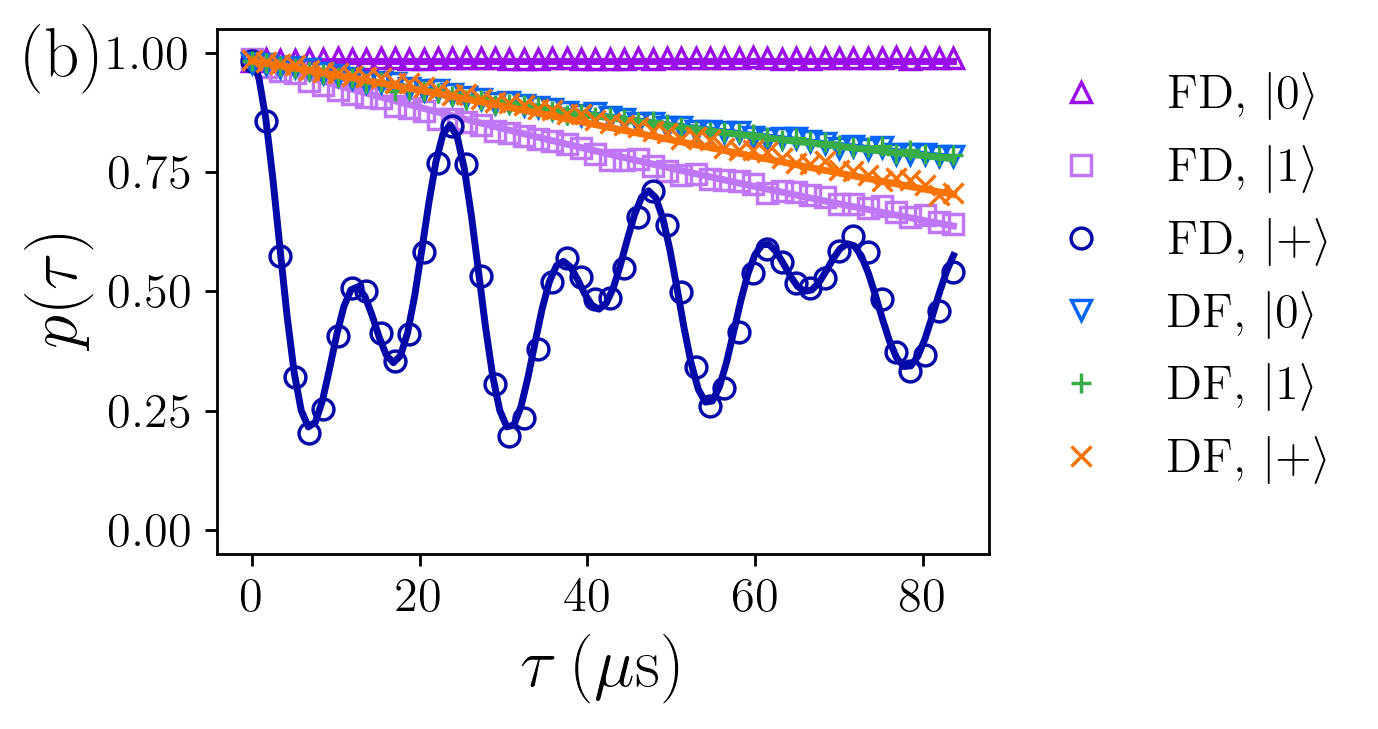

Saved: ../figures/fig_08_crosstalk_dd.pdf


In [10]:
markers = ['^', 's', 'o', 'v', '+', 'x']

plt.figure(figsize=(6, 3), dpi=250)

for exp_num, exp in enumerate(exp_type):
    c = colors_greg[exp_num]
    plt.plot(tt_exp, ps_exp_q[exp],
             ls='-', marker=markers[exp_num], lw=0,
             mfc='none', color=c,
             label=exp[:2] + r', $|%s\rangle$' % exp[-1])
    plt.plot(tt_sim, ps_sim[exp], ls='-', color=c, lw=2)

plt.tick_params(axis='both', labelsize=14)
plt.ylim(-0.05, 1.05)
plt.xlabel(r'$\tau\,(\mu\mathrm{s})$', size=20)
plt.ylabel(r'$p(\tau)$', size=20)
plt.legend(frameon=False, fontsize=14, bbox_to_anchor=(1, 1))
plt.text(-27, .95, '(b)', size=20)
plt.tight_layout()
plt.savefig('../figures/fig_08_crosstalk_dd.pdf', bbox_inches='tight')
plt.show()
print("Saved: ../figures/fig_08_crosstalk_dd.pdf")